In [73]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures


df = pd.read_csv("data/Data_Lesson1_ab_Startup.csv")

# EDA

In [74]:
df.head()

,No.,Profit,RnD,Adm,Marketing
0,1,192,165,137,472
1,2,192,163,151,444
2,3,191,153,101,408
3,4,183,144,119,383
4,5,166,142,91,366


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   No.        44 non-null     int64
 1   Profit     44 non-null     int64
 2   RnD        44 non-null     int64
 3   Adm        44 non-null     int64
 4   Marketing  44 non-null     int64
dtypes: int64(5)
memory usage: 1.8 KB


In [76]:
# Check NULL
print("Null:", df.isnull().sum().sum())
# Check duplicate
print("Duplicated:", df.duplicated().sum())

Null: 0
Duplicated: 0


# VN1: Thực hành xây dựng mô hình tính lợi nhuận (y) dựa trên chi phí Quản lý (x) (Adm) (Tiên)

In [77]:
# Chọn X, y
X = df[['Adm']]
y = df.Profit

# Chia tệp train, test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=0)

model_lin= LinearRegression()
model_lin.fit(X_train,y_train)
y_pred = model_lin.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R2 Score: {r2}")
print(f"RMSE: {rmse}")

R2 Score: -0.44053876303716377
RMSE: 38.45317793199347


# VN2 : Thực hành xây dựng mô hình tính lợi nhuận (y) dựa trên chi phí Marketing (x) (Marketing) (Thư)

In [78]:
# Chọn X, y
X=df[['Marketing']]
y=df.Profit

# Chia tệp train, test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=0)

model_lin= LinearRegression()
model_lin.fit(X_train,y_train)
y_pred = model_lin.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R2 Score: {r2}")
print(f"RMSE: {rmse}")

R2 Score: 0.5185071416392362
RMSE: 22.231291229736946


# VN3: Thực hành xây dựng mô hình tính lợi nhuận (y) dựa trên 2 loại chi phí (từng đôi 1) 
RnD, Marketing → Profit | RnD, Adm → Profit | Adm, Marketing → Profit


RnD - Marketing

In [79]:
# Chọn X, y
X=df[['RnD','Marketing']]
y=df.Profit

# Chia tệp train, test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=0)

model_lin= LinearRegression()
model_lin.fit(X_train,y_train)
y_pred = model_lin.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R2 Score: {r2}")
print(f"RMSE: {rmse}")

R2 Score: 0.9543627037594828
RMSE: 6.844310703113742


RnD - Adm

In [80]:
# Chọn X, y
X=df[['RnD','Adm']]
y=df.Profit

# Chia tệp train, test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=0)

model_lin= LinearRegression()
model_lin.fit(X_train,y_train)
y_pred = model_lin.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R2 Score: {r2}")
print(f"RMSE: {rmse}")

R2 Score: 0.9545045505904964
RMSE: 6.833665907995272


Adm - Marketing

In [81]:
# Chọn X, y
X=df[['Adm','Marketing']]
y=df.Profit

# Chia tệp train, test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=0)

model_lin= LinearRegression()
model_lin.fit(X_train,y_train)
y_pred = model_lin.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R2 Score: {r2}")
print(f"RMSE: {rmse}")

R2 Score: 0.41874647102575413
RMSE: 24.42601189877296


# VN4. Xây dựng mô hình polynomial cho data sau:
Dữ liệu được lấy thực tế từ 1 nhà máy, công nhân phải điều chỉnh biến WL (thông số của máy) để đạt được kích thước của sản phẩm biến R. Lập mô hình để dự báo WL cần điều chỉnh khi mà biết mong muốn kích thước của sản phẩm.

In [82]:
df = pd.read_excel("data/ZrO2-R1.xlsx")

# EDA

In [83]:
df.head()

,WL,R
0,380,12.078770
1,381,11.826804
2,382,12.090058
3,383,12.329763
4,384,12.224075


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401 entries, 0 to 400
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   WL      401 non-null    int64  
 1   R       401 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 6.4 KB


In [85]:
# Check NULL
print("Null:", df.isnull().sum().sum())
# Check duplicate
print("Duplicated:", df.duplicated().sum())

Null: 0
Duplicated: 0


In [86]:
# Chọn X,y
X = df[['R']].values
y = df['WL'].values

# Chia tệp train, test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [87]:
Poly_reg = PolynomialFeatures(degree=4)
X_train_poly = Poly_reg.fit_transform(X_train)
X_test_poly = Poly_reg.transform(X_test)
model_Pol = LinearRegression()
model_Pol.fit(X_train_poly, y_train)

y_pred_Pol = model_Pol.predict(X_test_poly)

r2 = r2_score(y_test, y_pred_Pol)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_Pol))
print(f"R2 Score: {r2}")
print(f"RMSE: {rmse}")

R2 Score: 0.46169074332397575
RMSE: 87.37873876569549


Ta thấy R2 Score = 0.46 chưa được tốt, thử tìm degree sao cho độ chính xác tốt hơn?

Sử dụng vòng lặp để tìm ra mô hình  tốt nhất

In [88]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Thay đổi siêu tham số degree và tính r2 và rmse tươgn ứng để chọn mô hình tốt nhất
r2_scores = []
rmse_values = []
degrees = range(1, 10)

for degree in degrees:
    Poly_reg = PolynomialFeatures(degree=degree)
    X_train_poly = Poly_reg.fit_transform(X_train)
    X_test_poly = Poly_reg.transform(X_test)

    model_Pol = LinearRegression()
    model_Pol.fit(X_train_poly, y_train)

    y_pred_Pol = model_Pol.predict(X_test_poly)

    r2 = r2_score(y_test, y_pred_Pol)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_Pol))

    r2_scores.append(r2)
    rmse_values.append(rmse)

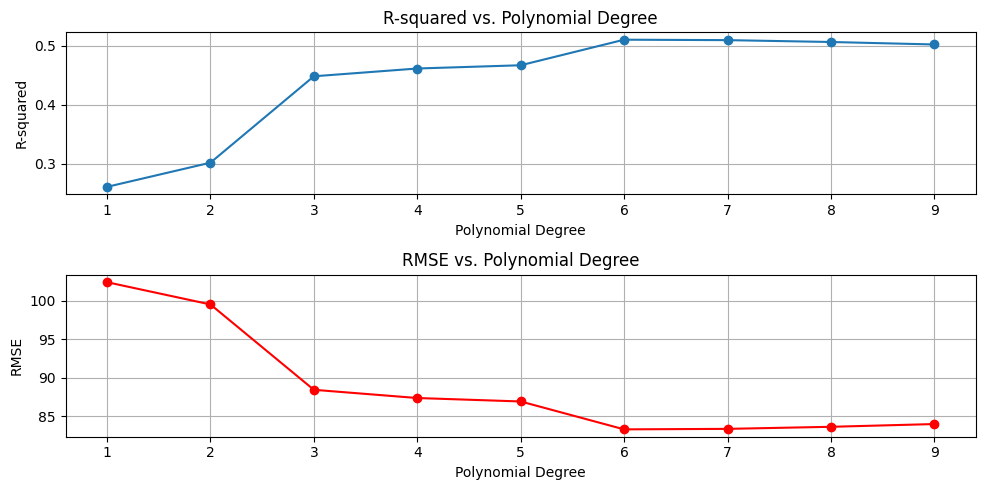

In [89]:
# Vẽ hình
fig, axes = plt.subplots(2, 1, figsize=(10, 5))

# R2
axes[0].plot(degrees, r2_scores, marker='o')
axes[0].set_title('R-squared vs. Polynomial Degree')
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('R-squared')
axes[0].grid(True)

# RMSE
axes[1].plot(degrees, rmse_values, marker='o', color='red')
axes[1].set_title('RMSE vs. Polynomial Degree')
axes[1].set_xlabel('Polynomial Degree')
axes[1].set_ylabel('RMSE')
axes[1].grid(True)

plt.tight_layout()
plt.show()